## Características temporales

**Series no estacionarias:** La media y varianza cambian por:
- Inflación de precios
- Estacionalidad climática
- Caída anómala en septiembre

**Memoria a corto plazo (Lags 1-2-7):** pasado inmediato tiene alta influencia en el presente. 

**Múltiples estacionalidades:** Patrones diarios, semanales y macrotendencias anuales coexisten. El suavizado de 7 días ayudó a aislar las tendencias de fondo.

**Posible shock en septiembre** que altera el comportamiento temporal.

# 0. Conexión con proyecto e importación de dataset

In [8]:
%load_ext autoreload
%autoreload 2

from temporal import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")

# 1. Variables continuas

# 1.1 Target ocupación - suavizado 7 días para convertirlo en serie

In [9]:
# las variables discretas, categóricas y algunas continuas carecen de evolución temporal. 
# Son atributos que no cambian en el tiempo

continuas_temp = ['listing_price','temp_max', 'temp_min','temp_mean', 'precipitation_mm']

In [10]:
ts_df = aggregate_daily_timeseries(df, target_col='is_occupied', continuous_cols=continuas_temp)

[+] Agregando serie temporal a frecuencia diaria...
[+] Serie agregada creada. Dimensiones: (329, 13)



📈 TESTS DE ESTACIONARIEDAD: tasa_ocupacion_suavizada_7d
1. Test ADF (Dickey-Fuller Aumentado):
   - p-valor: 0.1092
   - Conclusión: NO es estacionaria (Tiene tendencia/raíz unitaria)

2. Test KPSS:
   - p-valor: 0.0100
   - Conclusión: NO es estacionaria

3. Test Ljung-Box (Lag 7 - Autocorrelación global):
   - p-valor: 0.0000
   - Conclusión: Tiene autocorrelación fuerte
------------------------------------------------------------


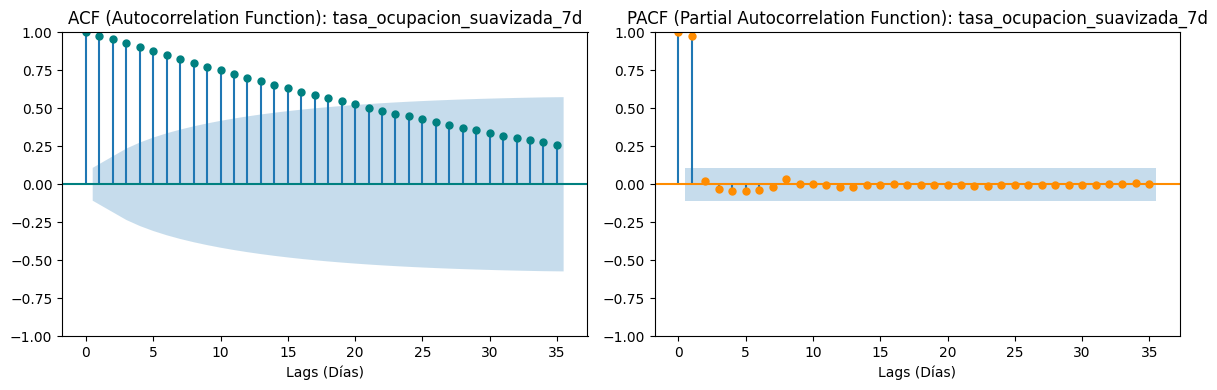

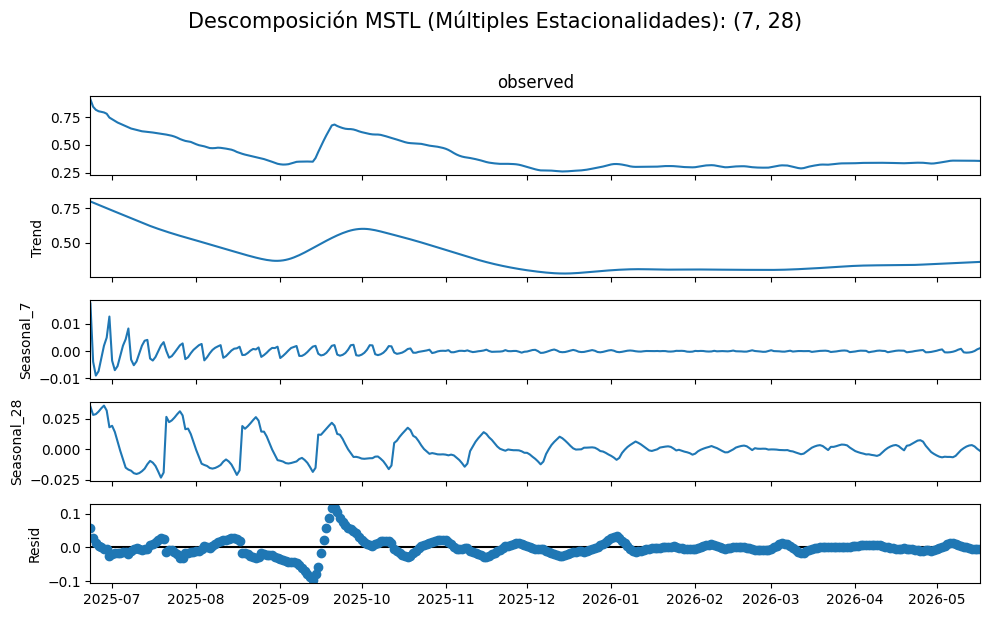


🧩 TEST DE RUIDO BLANCO (LJUNG-BOX) EN RESIDUOS MSTL
    Estadístico        p-valor        Interpretación
7    893.364219  1.300999e-188  Autocorrelación (⚠️)
14   964.912503  5.257157e-197  Autocorrelación (⚠️)
28  1209.109012  6.593550e-237  Autocorrelación (⚠️)

Conclusión General:
   ⚠️ Los residuos AÚN tienen autocorrelación (p < 0.05).
------------------------------------------------------------


In [7]:
# comprobar si la serie tiene o no un media y varianza estable a lo largo del tiempo 
# y averiguar si hay señal temporal subyacente
run_stationarity_tests(ts_df, 'tasa_ocupacion_suavizada_7d')

# comprobar la influencia del pasado inmediato en el estado presente
plot_autocorrelation(ts_df, 'tasa_ocupacion_suavizada_7d', lags=35) # 5 semanas atrás

# descomposicion con dos ciclos estacionales (semanal y mensual comercial)
mstl_res = plot_mstl_decomposition(ts_df, 'tasa_ocupacion_suavizada_7d', periods=(7, 28)) 
# al agregar la serie no se pueden investigar otros ciclos por no tener >= 4 ciclos  de trimestres, semestre, etc

# comprobar si la descomposición biestacional ha sacado toda la señal
test_mstl_residuals_ljungbox(mstl_res, lags=[7, 14, 28])

# 1.2 Variables predictoras continuas con componente temporal

## 1.2.1 Precio suavizado 7 días


📈 TESTS DE ESTACIONARIEDAD: listing_price_suavizada_7d
1. Test ADF (Dickey-Fuller Aumentado):
   - p-valor: 0.5471
   - Conclusión: NO es estacionaria (Tiene tendencia/raíz unitaria)

2. Test KPSS:
   - p-valor: 0.0100
   - Conclusión: NO es estacionaria

3. Test Ljung-Box (Lag 7 - Autocorrelación global):
   - p-valor: 0.0000
   - Conclusión: Tiene autocorrelación fuerte
------------------------------------------------------------


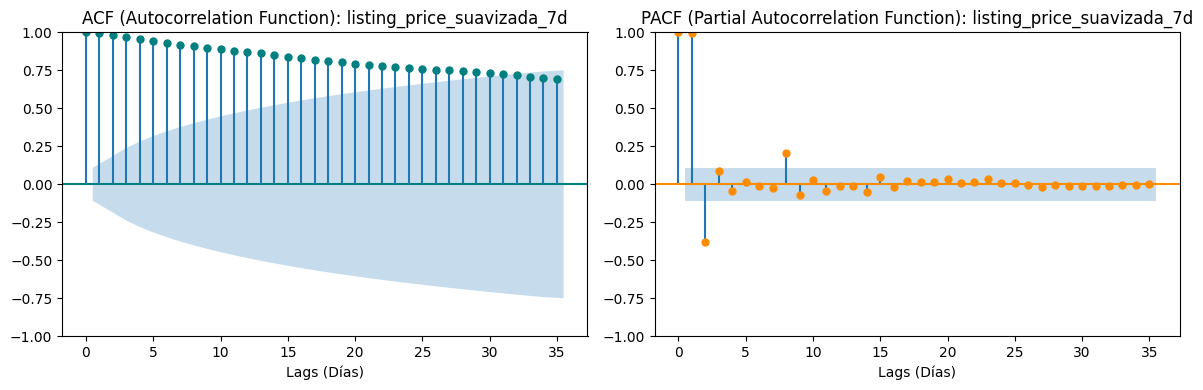

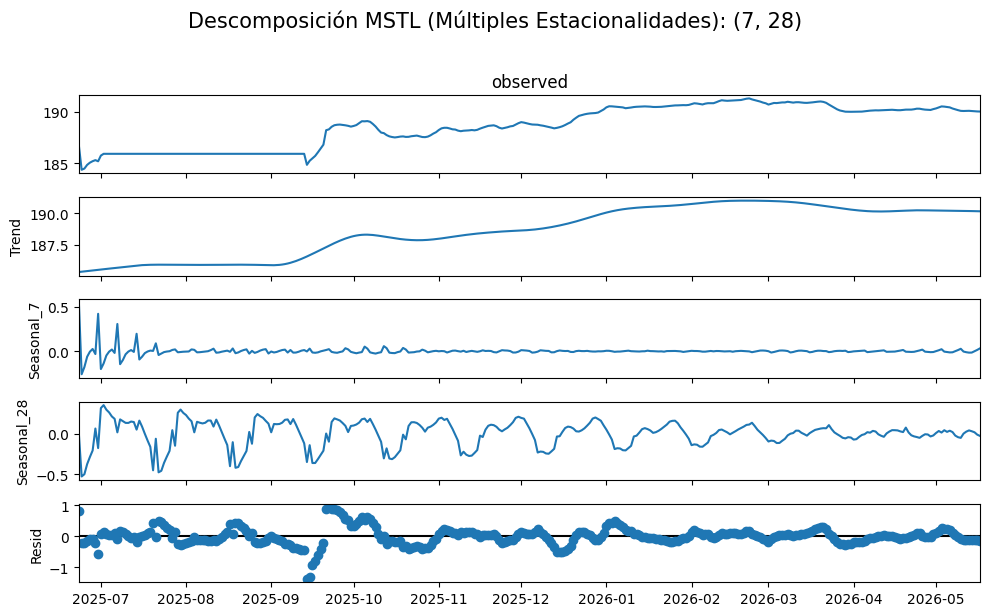


🧩 TEST DE RUIDO BLANCO (LJUNG-BOX) EN RESIDUOS MSTL
    Estadístico        p-valor        Interpretación
7    656.461402  1.672630e-137  Autocorrelación (⚠️)
14   704.007307  3.598745e-141  Autocorrelación (⚠️)
28  1222.388225  9.934356e-240  Autocorrelación (⚠️)

Conclusión General:
   ⚠️ Los residuos AÚN tienen autocorrelación (p < 0.05).
------------------------------------------------------------


In [13]:
run_stationarity_tests(ts_df, "listing_price_suavizada_7d")

# comprobar la influencia del pasado inmediato en el estado presente
plot_autocorrelation(ts_df, "listing_price_suavizada_7d", lags=35) # 5 semanas atrás

# descomposicion con dos ciclos estacionales (semanal y mensual comercial)
mstl_res = plot_mstl_decomposition(ts_df, "listing_price_suavizada_7d", periods=(7, 28)) 
# al agregar la serie no se pueden investigar otros ciclos por no tener >= 4 ciclos  de trimestres, semestre, etc

# comprobar si la descomposición biestacional ha sacado toda la señal
test_mstl_residuals_ljungbox(mstl_res, lags=[7, 14, 28])

## Meteorología suavizado 7 días


📈 TESTS DE ESTACIONARIEDAD: temp_mean_suavizada_7d
1. Test ADF (Dickey-Fuller Aumentado):
   - p-valor: 0.4241
   - Conclusión: NO es estacionaria (Tiene tendencia/raíz unitaria)

2. Test KPSS:
   - p-valor: 0.0100
   - Conclusión: NO es estacionaria

3. Test Ljung-Box (Lag 7 - Autocorrelación global):
   - p-valor: 0.0000
   - Conclusión: Tiene autocorrelación fuerte
------------------------------------------------------------


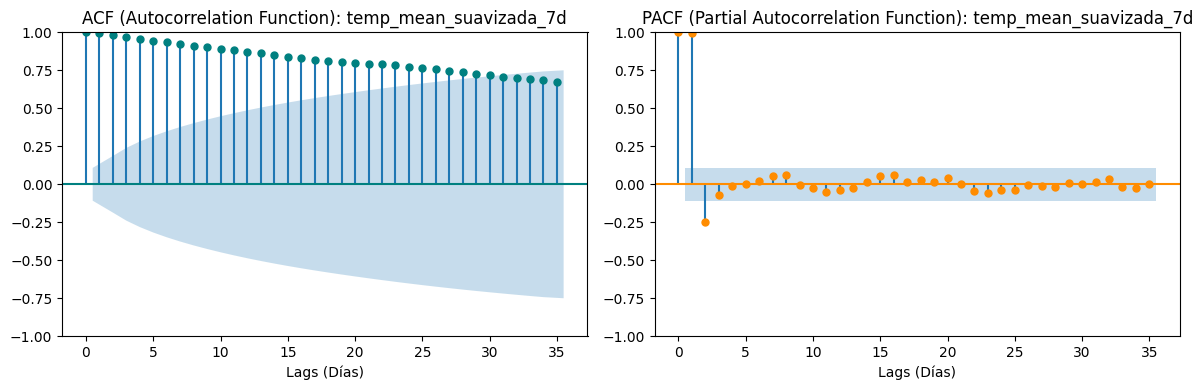

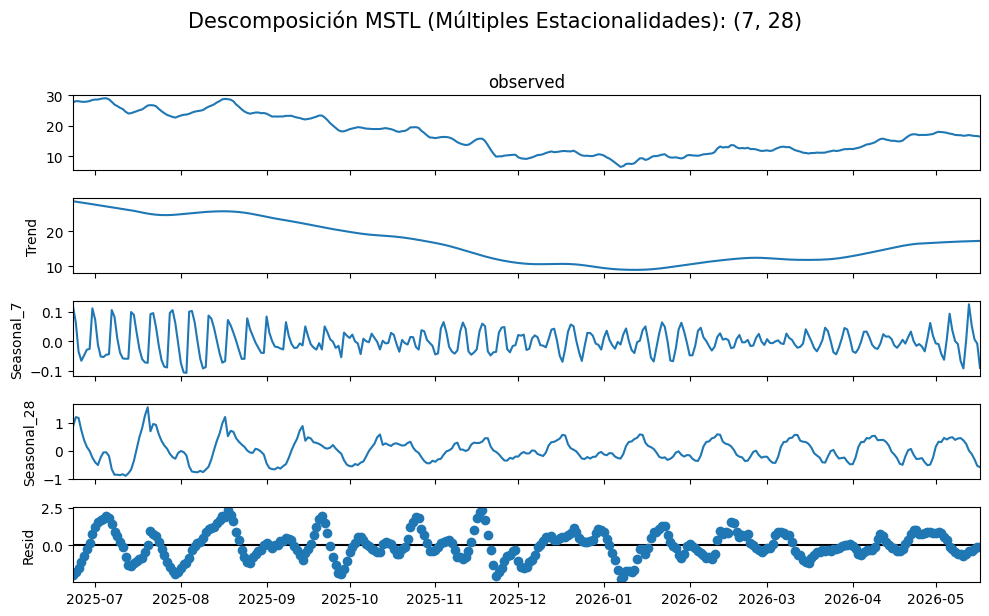


🧩 TEST DE RUIDO BLANCO (LJUNG-BOX) EN RESIDUOS MSTL
    Estadístico        p-valor        Interpretación
7    610.218522  1.534106e-127  Autocorrelación (⚠️)
14   727.414890  3.616164e-146  Autocorrelación (⚠️)
28   838.770574  1.501815e-158  Autocorrelación (⚠️)

Conclusión General:
   ⚠️ Los residuos AÚN tienen autocorrelación (p < 0.05).
------------------------------------------------------------


In [14]:
run_stationarity_tests(ts_df, "temp_mean_suavizada_7d")

# comprobar la influencia del pasado inmediato en el estado presente
plot_autocorrelation(ts_df, "temp_mean_suavizada_7d", lags=35) # 5 semanas atrás

# descomposicion con dos ciclos estacionales (semanal y mensual comercial)
mstl_res = plot_mstl_decomposition(ts_df, "temp_mean_suavizada_7d", periods=(7, 28)) 
# al agregar la serie no se pueden investigar otros ciclos por no tener >= 4 ciclos  de trimestres, semestre, etc

# comprobar si la descomposición biestacional ha sacado toda la señal
test_mstl_residuals_ljungbox(mstl_res, lags=[7, 14, 28])


📈 TESTS DE ESTACIONARIEDAD: precipitation_mm_suavizada_7d
1. Test ADF (Dickey-Fuller Aumentado):
   - p-valor: 0.0077
   - Conclusión: Es ESTACIONARIA

2. Test KPSS:
   - p-valor: 0.1000
   - Conclusión: Es ESTACIONARIA

3. Test Ljung-Box (Lag 7 - Autocorrelación global):
   - p-valor: 0.0000
   - Conclusión: Tiene autocorrelación fuerte
------------------------------------------------------------


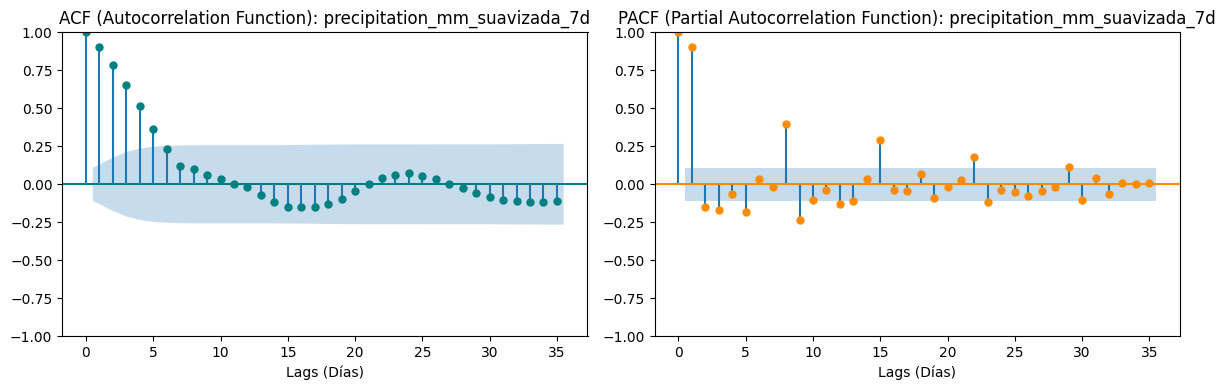

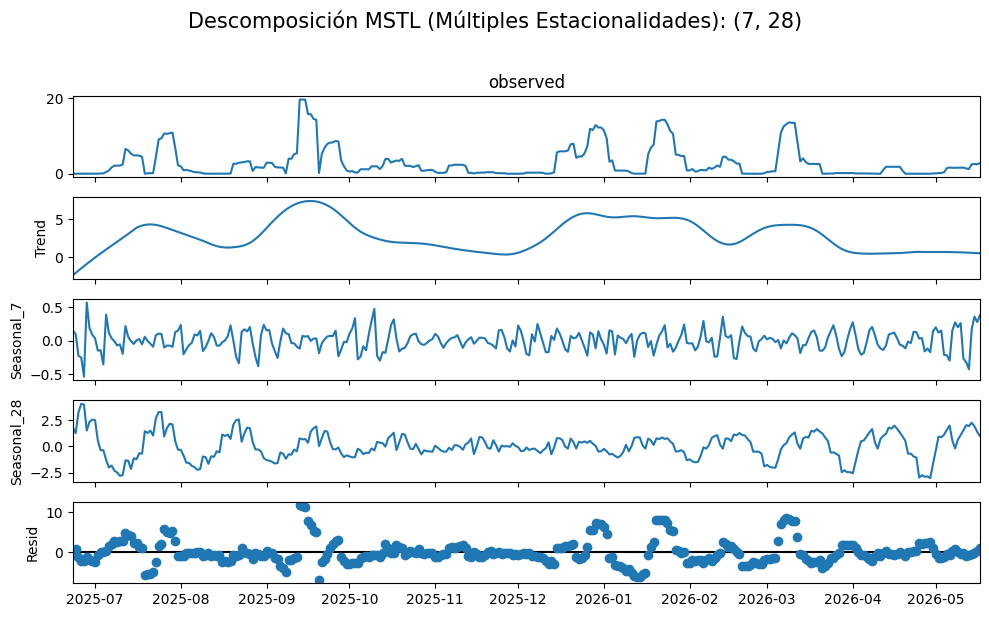


🧩 TEST DE RUIDO BLANCO (LJUNG-BOX) EN RESIDUOS MSTL
    Estadístico        p-valor        Interpretación
7    522.031202  1.467636e-108  Autocorrelación (⚠️)
14   748.220110  1.299373e-150  Autocorrelación (⚠️)
28   920.477612  9.072846e-176  Autocorrelación (⚠️)

Conclusión General:
   ⚠️ Los residuos AÚN tienen autocorrelación (p < 0.05).
------------------------------------------------------------


In [15]:
run_stationarity_tests(ts_df, "precipitation_mm_suavizada_7d")

# comprobar la influencia del pasado inmediato en el estado presente
plot_autocorrelation(ts_df, "precipitation_mm_suavizada_7d", lags=35) # 5 semanas atrás

# descomposicion con dos ciclos estacionales (semanal y mensual comercial)
mstl_res = plot_mstl_decomposition(ts_df, "precipitation_mm_suavizada_7d", periods=(7, 28)) 
# al agregar la serie no se pueden investigar otros ciclos por no tener >= 4 ciclos  de trimestres, semestre, etc

# comprobar si la descomposición biestacional ha sacado toda la señal
test_mstl_residuals_ljungbox(mstl_res, lags=[7, 14, 28])